            # WESAD 多被试工程全流程讲解 Notebook

            这份 notebook 用来系统讲解这个工程已经完成了什么、为什么这样设计、每一步产出了什么，以及最后能得出哪些结论。

            它的定位不是“重新训练所有模型”，而是“基于已经跑完的结果，顺着工程流程做一次完整复盘”。

            适合用在：
            - 给同学讲你做了什么
            - 给老师汇报当前阶段成果
            - 自己回头梳理项目主线
            


            ## 你会在这份 notebook 里看到什么

            1. 课题目标和这个工程的定位
            2. WESAD 数据集和 `S2_quest.csv` 是什么
            3. 工程里的代码模块分别负责什么
            4. 从原始信号到特征表的流程
            5. 为什么要比较 `random split` 和 `LOSO`
            6. 多模型和多模态实验的结果
            7. 窗长对比实验说明了什么
            8. ECG / EDA 特征扩展做了什么，目前结果如何
            9. 当前最重要的结论和下一步方向
            


In [1]:
            from pathlib import Path
            import json

            import matplotlib.pyplot as plt
            from matplotlib import font_manager
            import pandas as pd
            from IPython.display import Markdown, display

            CJK_FONT_CANDIDATES = [
                "Microsoft YaHei",
                "SimHei",
                "SimSun",
                "Microsoft JhengHei",
                "Noto Sans CJK SC",
            ]

            installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
            chosen_font = next((name for name in CJK_FONT_CANDIDATES if name in installed_fonts), None)
            if chosen_font is not None:
                plt.rcParams["font.sans-serif"] = [chosen_font] + CJK_FONT_CANDIDATES
            plt.rcParams["axes.unicode_minus"] = False

            ROOT = Path.cwd()

            ARTIFACT_60 = ROOT / "artifacts" / "wesad_experiments"
            ARTIFACT_30 = ROOT / "artifacts" / "wesad_experiments_w30_s15"
            ARTIFACT_10 = ROOT / "artifacts" / "wesad_experiments_w10_s5"
            WINDOW_COMPARE = ROOT / "artifacts" / "window_comparison"

            EXPANDED_60 = ROOT / "artifacts" / "wesad_experiments_expanded_60_30"
            EXPANDED_10 = ROOT / "artifacts" / "wesad_experiments_expanded_10_5"

            QUEST_PATH = ROOT / "WESAD" / "WESAD" / "S2" / "S2_quest.csv"
            QUEST_GUIDE = ROOT / "docs" / "WESAD_S2_quest_guide.md"

            print("项目根目录:", ROOT)
            print("60s/30s 结果:", ARTIFACT_60.exists())
            print("30s/15s 结果:", ARTIFACT_30.exists())
            print("10s/5s 结果:", ARTIFACT_10.exists())
            print("窗长汇总结果:", WINDOW_COMPARE.exists())
            print("扩展特征 60s/30s:", EXPANDED_60.exists())
            print("扩展特征 10s/5s:", EXPANDED_10.exists())
            print("S2_quest.csv:", QUEST_PATH.exists())
            print("问卷说明文档:", QUEST_GUIDE.exists())
            print("当前绘图中文字体:", chosen_font)
            


项目根目录: c:\Users\张家辉\Desktop\ECG EDA
60s/30s 结果: True
30s/15s 结果: True
10s/5s 结果: True
窗长汇总结果: True
扩展特征 60s/30s: True
扩展特征 10s/5s: True
S2_quest.csv: True
问卷说明文档: True
当前绘图中文字体: Microsoft YaHei


            ## 1. 项目目标

            这个工程的主线不是直接让模型去吃整段原始波形，而是把任务拆成一条清晰的工程流程：

            `原始 ECG / EDA / 温度 / ACC -> 预处理和质量控制 -> 窗口级特征 -> 机器学习模型 -> 风险/状态结论`

            当前已经完成的是一个比较扎实的 WESAD 原型：
            - 从单被试教学理解，推进到了多被试正式实验
            - 用 `ECG + EDA + TEMP` 做窗口级状态分类
            - 比较了多个机器学习模型
            - 正式使用 `LOSO` 做跨人泛化评估
            - 做了窗长比较实验
            - 新增了一轮 ECG / EDA 特征扩展实验
            


            ## 2. 工程结构总览

            先不要一上来读全部文件。这个项目可以按四层理解：

            - 运行入口：`scripts/train_wesad.py`
            - 数据读取：`src/anxiety_monitor/datasets/wesad.py`
            - 特征工程：`src/anxiety_monitor/features.py`
            - 实验协议：`src/anxiety_monitor/experiments.py`

            另外还有：
            - `src/anxiety_monitor/model.py`：模型和默认特征顺序
            - `src/anxiety_monitor/pipeline.py`：把整条流程串起来
            - `artifacts/...`：已经跑出来的实验结果
            


In [2]:
            project_map = pd.DataFrame(
                [
                    ["scripts/train_wesad.py", "运行多被试 WESAD 实验，支持 random split / LOSO 和不同窗长"],
                    ["src/anxiety_monitor/datasets/wesad.py", "读取 WESAD subject 的原始 pickle 数据"],
                    ["src/anxiety_monitor/features.py", "从 ECG / EDA / TEMP / ACC 提取窗口级特征"],
                    ["src/anxiety_monitor/experiments.py", "定义特征组合、模型集合和评估协议"],
                    ["src/anxiety_monitor/model.py", "模型相关定义和默认特征顺序"],
                    ["artifacts/wesad_experiments", "60s/30s baseline 实验结果"],
                    ["artifacts/wesad_experiments_w30_s15", "30s/15s baseline 实验结果"],
                    ["artifacts/wesad_experiments_w10_s5", "10s/5s baseline 实验结果"],
                    ["artifacts/wesad_experiments_expanded_60_30", "60s/30s 扩展特征实验结果"],
                    ["artifacts/wesad_experiments_expanded_10_5", "10s/5s 扩展特征实验目录"],
                    ["artifacts/window_comparison", "三组窗长的汇总比较结果"],
                ],
                columns=["路径", "作用"],
            )
            project_map
            


,路径,作用
0,scripts/train_wesad.py,运行多被试 WESAD 实验，支持 random split / LOSO 和不同窗长
1,src/anxiety_monitor/datasets/wesad.py,读取 WESAD subject 的原始 pickle 数据
2,src/anxiety_monitor/features.py,从 ECG / EDA / TEMP / ACC 提取窗口级特征
3,src/anxiety_monitor/experiments.py,定义特征组合、模型集合和评估协议
4,src/anxiety_monitor/model.py,模型相关定义和默认特征顺序
5,artifacts/wesad_experiments,60s/30s baseline 实验结果
6,artifacts/wesad_experiments_w30_s15,30s/15s baseline 实验结果
7,artifacts/wesad_experiments_w10_s5,10s/5s baseline 实验结果
8,artifacts/wesad_experiments_expanded_60_30,60s/30s 扩展特征实验结果
9,artifacts/wesad_experiments_expanded_10_5,10s/5s 扩展特征实验目录


            ## 3. 数据集：WESAD 和 `S2_quest.csv`

            WESAD 是一个可穿戴生理信号数据集。你在这个项目里主要用了：

            - ECG
            - EDA
            - TEMP
            - ACC

            这些信号最终不会直接喂给分类器，而是会先做切窗和特征提取。
            


In [3]:
            feature_table_60 = pd.read_csv(ARTIFACT_60 / "feature_table.csv")

            print("60s/30s 特征表 shape:", feature_table_60.shape)
            print("受试者数:", feature_table_60["subject_id"].nunique())
            print("窗口标签分布:")
            display(feature_table_60["label_name"].value_counts().rename_axis("label_name").reset_index(name="count"))

            print("每个受试者对应的窗口数:")
            display(
                feature_table_60.groupby("subject_id")
                .size()
                .rename("n_windows")
                .reset_index()
                .sort_values("subject_id")
            )
            


60s/30s 特征表 shape: (793, 32)
受试者数: 15
窗口标签分布:


,label_name,count
0,low,600
1,medium,136
2,high,57


每个受试者对应的窗口数:


,subject_id,n_windows
0,S10,76
1,S11,42
2,S13,35
3,S14,45
4,S15,58
5,S16,48
6,S17,72
7,S2,45
8,S3,49
9,S4,51


            ### `feature_table.csv` 是什么

            这是整个工程里非常关键的一步。

            它说明模型真正吃进去的不是原始波形，而是“窗口级特征表”：

            - 每一行：一个时间窗口
            - 每一列：一个特征
            - `subject_id`：来自哪个受试者
            - `label_name`：当前窗口的标签

            这也正是“生理信号工程”和“直接端到端黑盒”之间的区别：你能明确知道模型到底在看什么。
            


            ### `S2_quest.csv` 是什么

            这个文件不是 ECG/EDA 波形本身，而是 WESAD 的问卷和实验元数据。

            它里面记录的是：
            - 实验阶段顺序
            - 各阶段开始和结束时间
            - PANAS / STAI / DIM / SSSQ 等量表信息

            所以它更适合被理解为“实验背景和主观标签辅助信息”，而不是主信号文件。
            


In [4]:
            with open(QUEST_PATH, "r", encoding="utf-8") as f:
                quest_preview = [next(f).rstrip("\n") for _ in range(16)]

            for line in quest_preview:
                print(line)
            


# Subj;S2;;;;;;;;;;;;;;;;;;;;;;;;;
# ORDER;Base;TSST;Medi 1;Fun;Medi 2;sRead;fRead;;;;;;;;;;;;;;;;;;;
# START;7.08;39.55;70.19;81.25;93.38;54.42;89.51;;;;;;;;;;;;;;;;;;;
# END;26.32;50.3;77.1;87.47;100.15;56.07;91.15;;;;;;;;;;;;;;;;;;;
;;;;;;;;;;;;;;;;;;;;;;;;;;
# PANAS;1;1;3;2;1;3;1;1;1;2;2;2;2;1;4;3;4;4;2;2;2;1;2;1;;
# PANAS;3;2;4;1;3;3;1;2;1;4;2;4;3;1;5;4;4;4;2;3;3;3;2;1;3;1
# PANAS;1;1;2;3;1;2;1;1;1;1;1;1;3;1;2;1;2;3;1;1;1;1;4;1;;
# PANAS;1;1;2;3;1;1;1;1;1;1;1;1;2;1;4;1;1;3;1;1;1;2;3;1;;
# PANAS;1;1;1;2;1;1;1;1;1;1;1;1;2;1;2;1;1;2;1;1;1;1;3;1;;
;;;;;;;;;;;;;;;;;;;;;;;;;;
# STAI;3;2;1;4;2;3;;;;;;;;;;;;;;;;;;;;
# STAI;1;3;2;1;3;1;;;;;;;;;;;;;;;;;;;;
# STAI;4;1;1;4;2;4;;;;;;;;;;;;;;;;;;;;
# STAI;3;1;1;3;1;4;;;;;;;;;;;;;;;;;;;;
# STAI;4;1;1;4;1;4;;;;;;;;;;;;;;;;;;;;


In [5]:
            if QUEST_GUIDE.exists():
                print("问卷说明文档路径:", QUEST_GUIDE)
                guide_lines = QUEST_GUIDE.read_text(encoding="utf-8").splitlines()[:20]
                print("\n".join(guide_lines))
            else:
                print("没有找到额外的问卷说明文档。")
            


问卷说明文档路径: c:\Users\张家辉\Desktop\ECG EDA\docs\WESAD_S2_quest_guide.md
# WESAD `S2_quest.csv` 说明文档

这份文档用于帮助读者看懂：

- `WESAD/WESAD/S2/S2_quest.csv`

注意：

- 这是 **WESAD 原始数据文件**
- 当前项目**不会直接修改原文件**
- 这里只做解释和注释，保证原始数据可追溯

## 1. 这个文件为什么看起来不像普通 CSV

它虽然叫 `.csv`，但有两个特点：

1. 使用的是 `;` 作为分隔符，而不是逗号
2. 很多行以 `#` 开头，表示这是带标签的记录行

所以它更像一种“半结构化问卷元数据文件”，而不是规整的表格型 CSV。


            ## 4. 从原始信号到模型输入：工程流水线

            当前工程的核心流程可以概括成 5 步：

            1. 读取 WESAD 原始信号
            2. 按固定窗长和步长切窗
            3. 对每个窗口提取 ECG / EDA / TEMP / ACC 特征
            4. 形成统一特征表
            5. 用机器学习模型做评估

            其中，最关键的一步是“原始信号变成结构化特征”。
            


In [6]:
            feature_columns = [
                col for col in feature_table_60.columns
                if col not in {"subject_id", "window_start_s", "window_end_s", "label", "label_name"}
            ]

            print("特征总数:", len(feature_columns))
            display(pd.DataFrame({"feature_name": feature_columns}).head(25))
            


特征总数: 27


,feature_name
0,overall_quality
1,is_usable
2,hr_mean
3,rr_mean_ms
4,rmssd_ms
5,sdnn_ms
6,pnn50
7,eda_scl_mean
8,eda_scr_count
9,eda_scr_amplitude_mean


            ### 当前 baseline 特征大致分成几类

            - ECG：如 `hr_mean`、`rr_mean_ms`、`rmssd_ms`、`sdnn_ms`、`pnn50`
            - EDA：如 `eda_scl_mean`、`eda_scr_count`、`eda_scr_amplitude_mean`
            - TEMP：如 `temp_mean`、`temp_std`、`temp_slope`
            - ACC：主要用于活动和质量辅助

            也就是说，项目一开始先做的是“稳妥、可解释、可复现”的基础特征版本。
            


            ## 5. 为什么一定要比较 `random split` 和 `LOSO`

            这是这个工程里最重要的方法学点之一。

            `random split`：
            - 把所有窗口混在一起随机切分训练集和测试集
            - 同一个人的窗口可能同时出现在训练集和测试集里
            - 结果通常偏高

            `LOSO`：
            - Leave-One-Subject-Out
            - 每次留一个受试者做测试，其他人做训练
            - 更接近真实“新来一个人时能不能泛化”的场景
            


In [7]:
            random_60 = pd.read_csv(ARTIFACT_60 / "random_split_summary.csv")
            loso_60 = pd.read_csv(ARTIFACT_60 / "loso_summary.csv")

            print("Random split 前 5 组结果")
            display(random_60.head())

            print("LOSO 前 5 组结果")
            display(loso_60.head())
            


Random split 前 5 组结果


,model_name,feature_set_name,accuracy,macro_f1,n_train_windows,n_test_windows
0,RF,ECG+EDA+TEMP,0.930818,0.895141,634,159
1,Boosting,ECG+EDA+TEMP,0.924528,0.883825,634,159
2,SVM,ECG+EDA+TEMP,0.735849,0.722222,634,159
3,SVM,ECG-only,0.742138,0.666862,634,159
4,Boosting,EDA-only,0.823899,0.636601,634,159


LOSO 前 5 组结果


,model_name,feature_set_name,accuracy,macro_f1,subject_accuracy_mean,subject_accuracy_std,subject_macro_f1_mean,subject_macro_f1_std
0,Boosting,ECG+EDA+TEMP,0.727617,0.526258,0.733918,0.133465,0.476536,0.150966
1,RF,ECG+EDA+TEMP,0.756620,0.496146,0.753559,0.130429,0.433985,0.151108
2,LR,ECG+EDA+TEMP,0.544767,0.454138,0.520405,0.246083,0.416189,0.215537
3,RF,EDA-only,0.720050,0.406282,0.730855,0.082156,0.411340,0.110210
4,RF,ECG-only,0.702396,0.461889,0.713938,0.124526,0.395045,0.150341


In [8]:
            protocol_compare = random_60.merge(
                loso_60,
                on=["model_name", "feature_set_name"],
                suffixes=("_random", "_loso"),
            )
            protocol_compare["macro_f1_gap"] = (
                protocol_compare["macro_f1_random"] - protocol_compare["subject_macro_f1_mean"]
            )
            protocol_compare = protocol_compare.sort_values("macro_f1_gap", ascending=False)

            protocol_compare[[
                "model_name",
                "feature_set_name",
                "macro_f1_random",
                "subject_macro_f1_mean",
                "macro_f1_gap",
            ]]
            


,model_name,feature_set_name,macro_f1_random,subject_macro_f1_mean,macro_f1_gap
0,RF,ECG+EDA+TEMP,0.895141,0.433985,0.461156
1,Boosting,ECG+EDA+TEMP,0.883825,0.476536,0.407289
2,SVM,ECG+EDA+TEMP,0.722222,0.367491,0.354731
4,Boosting,EDA-only,0.636601,0.349972,0.286630
3,SVM,ECG-only,0.666862,0.386606,0.280256
6,RF,TEMP-only,0.613076,0.345438,0.267638
7,Boosting,ECG-only,0.606750,0.388917,0.217833
5,RF,EDA-only,0.618114,0.411340,0.206774
10,LR,ECG-only,0.531616,0.347488,0.184129
9,RF,ECG-only,0.572296,0.395045,0.177250


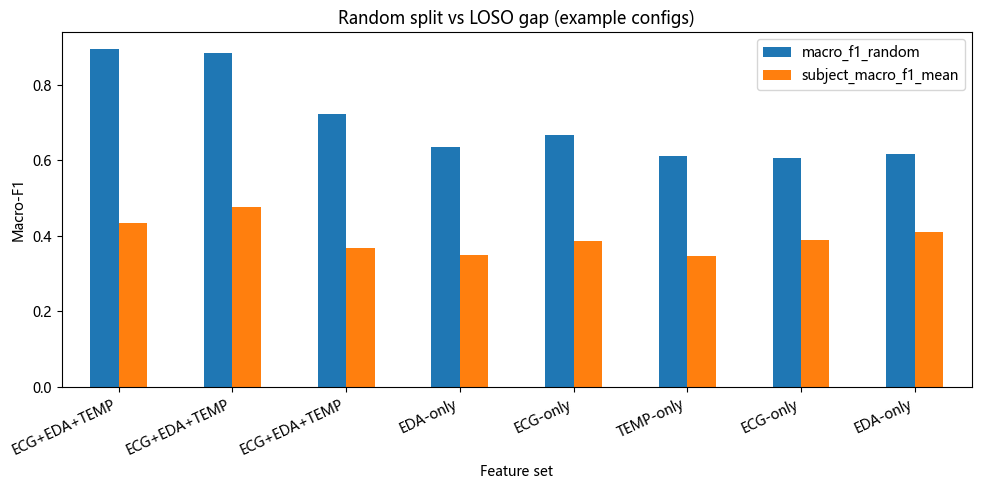

In [9]:
            top_gap = protocol_compare.head(8).copy()
            ax = top_gap.plot(
                x="feature_set_name",
                y=["macro_f1_random", "subject_macro_f1_mean"],
                kind="bar",
                figsize=(10, 5),
            )
            ax.set_title("Random split vs LOSO gap (example configs)")
            ax.set_ylabel("Macro-F1")
            ax.set_xlabel("Feature set")
            plt.xticks(rotation=25, ha="right")
            plt.tight_layout()
            plt.show()
            


            ### 这一步应该怎么讲结论

            如果 `random split` 明显高于 `LOSO`，说明：

            - 模型在“见过相似个体”的情况下表现很好
            - 但真正跨人泛化更难
            - 所以正式汇报时应该以 `LOSO` 为主，而不是只报随机切分结果
            


            ## 6. 多模型、多模态 baseline 结果

            在 baseline 版本里，已经比较了 4 个传统机器学习模型：

            - Logistic Regression
            - SVM
            - Random Forest
            - Boosting

            以及 4 套特征组合：

            - ECG-only
            - EDA-only
            - TEMP-only
            - ECG+EDA+TEMP
            


In [10]:
            loso_pivot_60 = loso_60.pivot(
                index="model_name",
                columns="feature_set_name",
                values="subject_macro_f1_mean",
            )
            loso_pivot_60
            


feature_set_name,ECG+EDA+TEMP,ECG-only,EDA-only,TEMP-only
model_name,,,,
Boosting,0.476536,0.388917,0.349972,0.353608
LR,0.416189,0.347488,0.209803,0.229166
RF,0.433985,0.395045,0.411340,0.345438
SVM,0.367491,0.386606,0.224044,0.223690


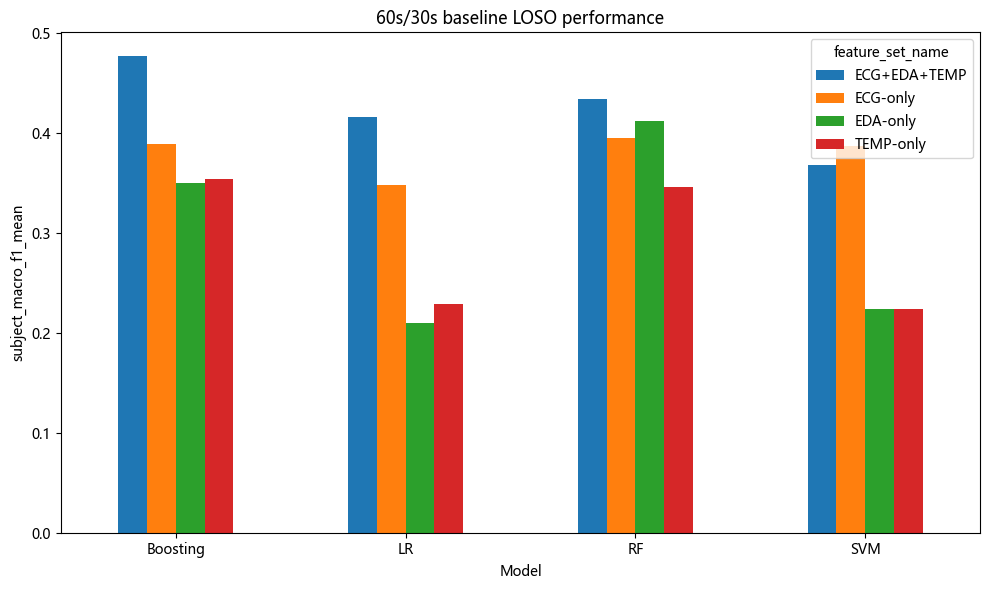

In [11]:
            ax = loso_pivot_60.plot(kind="bar", figsize=(10, 6))
            ax.set_title("60s/30s baseline LOSO performance")
            ax.set_ylabel("subject_macro_f1_mean")
            ax.set_xlabel("Model")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
            


            ### 这里重点看什么

            - 最好的模型是谁
            - 融合特征 `ECG+EDA+TEMP` 是否整体优于单模态
            - `EDA-only` 和 `ECG-only` 谁更稳定
            - `TEMP-only` 是否更适合作为辅助模态
            


In [12]:
            best_loso_row = loso_60.iloc[0]
            print("当前 60s/30s baseline 最优配置：")
            print(best_loso_row.to_string())
            


当前 60s/30s baseline 最优配置：
model_name                   Boosting
feature_set_name         ECG+EDA+TEMP
accuracy                     0.727617
macro_f1                     0.526258
subject_accuracy_mean        0.733918
subject_accuracy_std         0.133465
subject_macro_f1_mean        0.476536
subject_macro_f1_std         0.150966


            ## 7. 窗长对比实验

            baseline 阶段已经比较了三组窗长：

            - `60s / 30s`
            - `30s / 15s`
            - `10s / 5s`

            这个实验要回答的问题是：

            > 把窗口缩短以后，样本量确实会增加，但模型会不会更难做？
            


In [13]:
            window_summary = pd.read_csv(WINDOW_COMPARE / "window_comparison_summary.csv")
            window_summary
            


,window_config,n_windows,n_subjects,best_loso_model,best_loso_feature_set,best_loso_subject_macro_f1_mean,best_loso_subject_macro_f1_std,best_random_model,best_random_feature_set,best_random_macro_f1
0,60s_30s,793,15,Boosting,ECG+EDA+TEMP,0.476536,0.150966,RF,ECG+EDA+TEMP,0.895141
1,30s_15s,1755,15,SVM,ECG+EDA+TEMP,0.446951,0.143889,RF,ECG+EDA+TEMP,0.906686
2,10s_5s,5760,15,LR,EDA-only,0.453122,0.145138,RF,ECG+EDA+TEMP,0.941342


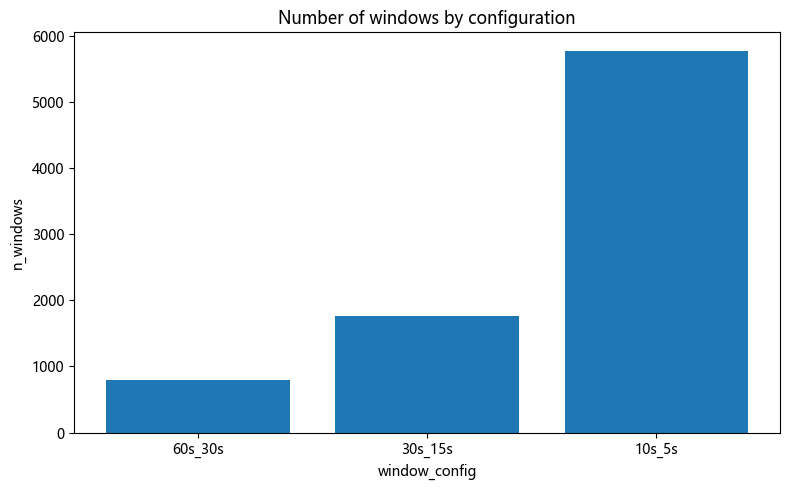

In [14]:
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.bar(window_summary["window_config"], window_summary["n_windows"])
            ax.set_title("Number of windows by configuration")
            ax.set_ylabel("n_windows")
            ax.set_xlabel("window_config")
            plt.tight_layout()
            plt.show()
            


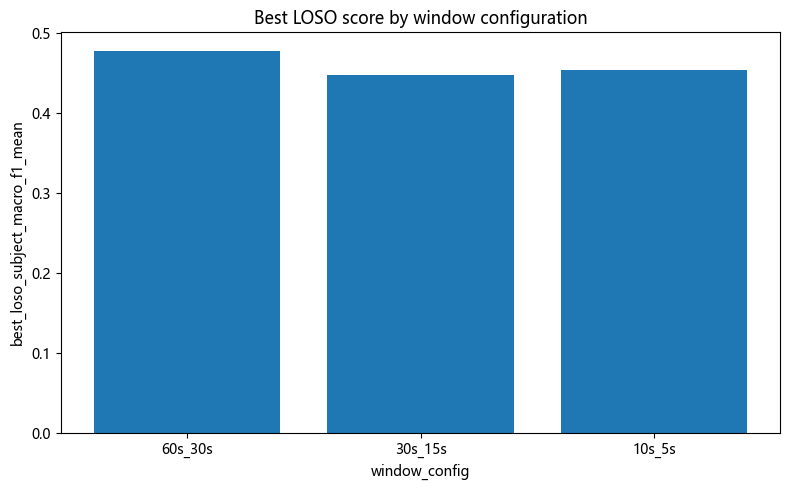

In [15]:
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.bar(window_summary["window_config"], window_summary["best_loso_subject_macro_f1_mean"])
            ax.set_title("Best LOSO score by window configuration")
            ax.set_ylabel("best_loso_subject_macro_f1_mean")
            ax.set_xlabel("window_config")
            plt.tight_layout()
            plt.show()
            


In [16]:
            window_full = pd.read_csv(WINDOW_COMPARE / "window_comparison_loso_full.csv")
            target_sets = ["ECG+EDA+TEMP", "ECG-only", "EDA-only", "TEMP-only"]
            best_per_set = (
                window_full[window_full["feature_set_name"].isin(target_sets)]
                .sort_values(
                    ["window_config", "feature_set_name", "subject_macro_f1_mean"],
                    ascending=[True, True, False],
                )
                .groupby(["window_config", "feature_set_name"], as_index=False)
                .first()
            )
            best_per_set.pivot(
                index="feature_set_name",
                columns="window_config",
                values="subject_macro_f1_mean",
            )
            


window_config,10s_5s,30s_15s,60s_30s
feature_set_name,,,
ECG+EDA+TEMP,0.447690,0.446951,0.476536
ECG-only,0.396865,0.398025,0.395045
EDA-only,0.453122,0.391316,0.411340
TEMP-only,0.322236,0.373455,0.353608


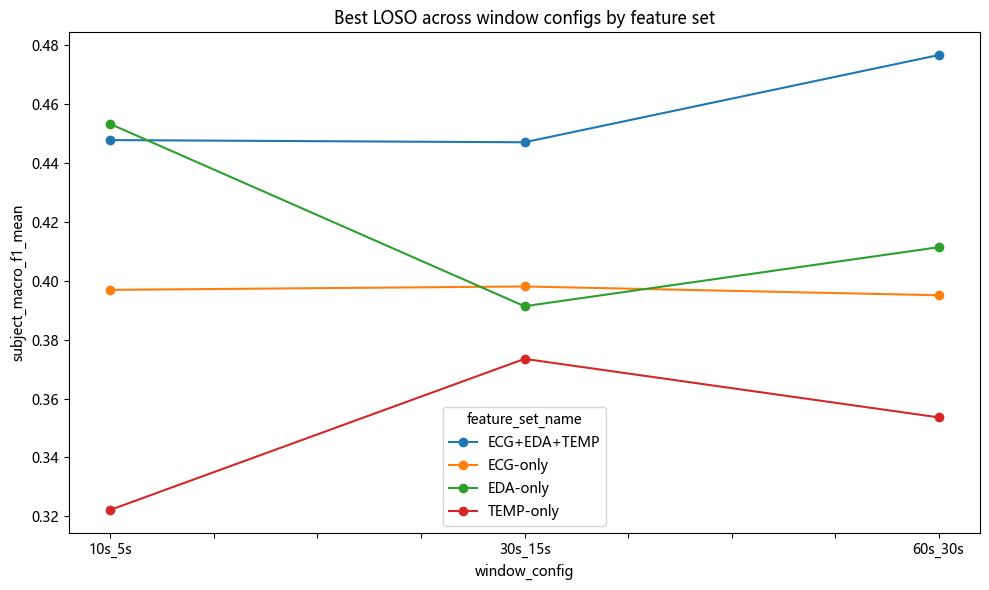

In [17]:
            pivot_compare = best_per_set.pivot(
                index="feature_set_name",
                columns="window_config",
                values="subject_macro_f1_mean",
            )
            ax = pivot_compare.T.plot(marker="o", figsize=(10, 6))
            ax.set_title("Best LOSO across window configs by feature set")
            ax.set_ylabel("subject_macro_f1_mean")
            ax.set_xlabel("window_config")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
            


            ### 窗长实验目前说明了什么

            已有结果表明：

            - 窗口缩短后，样本量显著增加
            - 但最佳 LOSO 表现并没有因为样本数变多而必然提升
            - `60s / 30s` 目前仍然是更稳的主配置
            - `10s / 5s` 更能体现 EDA 在短时反应上的作用
            


            ## 8. 被试间差异：为什么 LOSO 更真实

            `LOSO` 的另一个好处是，可以直接看到：

            - 哪些受试者更容易
            - 哪些受试者更难
            - 模型是否对不同个体差异很敏感
            


In [18]:
            with open(ARTIFACT_60 / "loso_results.json", "r", encoding="utf-8") as f:
                loso_results_60 = json.load(f)["results"]

            best_result_60 = max(
                loso_results_60,
                key=lambda item: item["subject_level_summary"]["macro_f1_mean"],
            )

            fold_df_60 = pd.DataFrame(best_result_60["fold_results"]).sort_values("macro_f1", ascending=False)
            print("最佳 baseline LOSO 配置:", best_result_60["model_name"], "+", best_result_60["feature_set_name"])
            fold_df_60[["test_subject", "accuracy", "macro_f1", "n_test_windows"]]
            


最佳 baseline LOSO 配置: Boosting + ECG+EDA+TEMP


,test_subject,accuracy,macro_f1,n_test_windows
5,S16,0.854167,0.749814,48
11,S6,0.869565,0.642857,46
13,S8,0.803922,0.628788,51
12,S7,0.793103,0.624113,58
6,S17,0.625000,0.557950,72
7,S2,0.777778,0.519231,45
14,S9,0.788462,0.509205,52
0,S10,0.578947,0.491703,76
4,S15,0.586207,0.460317,58
9,S4,0.803922,0.445652,51


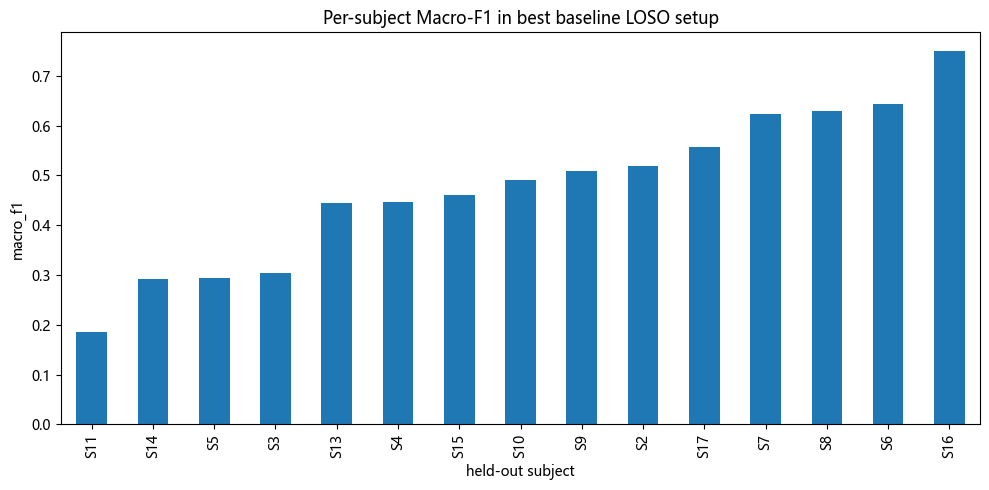

In [19]:
            ax = (
                fold_df_60.sort_values("macro_f1")
                .plot(x="test_subject", y="macro_f1", kind="bar", figsize=(10, 5), legend=False)
            )
            ax.set_title("Per-subject Macro-F1 in best baseline LOSO setup")
            ax.set_ylabel("macro_f1")
            ax.set_xlabel("held-out subject")
            plt.tight_layout()
            plt.show()
            


            ### 这一步的意义

            如果不同受试者差异明显，说明：

            - 个体差异很强
            - 跨人泛化依然是难点
            - 后续做个人基线、域适配、更多模态融合，都是合理方向
            


            ## 9. 特征扩展：为什么要扩 ECG / EDA

            baseline 版虽然已经能工作，但 ECG 和 EDA 的特征仍然偏基础。

            所以这一轮做了“中等规模、可解释”的特征扩展，目标不是盲目堆特征数量，而是验证：

            - 新特征能不能提升 LOSO
            - 提升更多出现在 ECG、EDA，还是融合模型
            - 长窗和短窗对特征类型有没有不同偏好
            


            ### 这一轮新增了什么

            ECG 新增了：
            - 时域 HRV：`hr_std`、`rr_std_ms`、`rr_min_ms`、`rr_max_ms`、`median_rr_ms`、`median_hr`、`sdsd_ms`、`pnn20`
            - 统计特征：`ecg_mean`、`ecg_std`、`ecg_skewness`、`ecg_kurtosis`
            - 频域摘要：`ecg_fft_entropy`、`ecg_mean_frequency`、`ecg_zero_crossing_rate`
            - 长窗可用的 HRV 频域：`lf_power`、`hf_power`、`lf_hf_ratio`

            EDA 新增了：
            - tonic/phasic 统计：`eda_tonic_std`、`eda_tonic_slope`、`eda_phasic_mean`、`eda_phasic_max`
            - phasic 分布：`eda_phasic_skewness`、`eda_phasic_kurtosis`
            - SCR 事件特征：`eda_scr_amplitude_std`、`eda_scr_amplitude_max`、`eda_scr_area`
            - 频域和复杂度：`eda_fft_entropy`、`eda_mean_frequency`、`eda_zero_crossing_rate`、`eda_nld`
            


In [20]:
            expanded_loso_60 = pd.read_csv(EXPANDED_60 / "loso_summary.csv")
            expanded_compare_60 = pd.read_csv(EXPANDED_60 / "baseline_vs_expanded_summary.csv")

            print("扩展特征 60s/30s LOSO 前 10 行")
            display(expanded_loso_60.head(10))

            print("baseline vs expanded 对比")
            display(expanded_compare_60)
            


扩展特征 60s/30s LOSO 前 10 行


,model_name,feature_set_name,accuracy,macro_f1,subject_accuracy_mean,subject_accuracy_std,subject_macro_f1_mean,subject_macro_f1_std
0,LR,ECG+EDA+TEMP-expanded,0.658260,0.597574,0.649490,0.200433,0.520591,0.189596
1,Boosting,ECG+EDA+TEMP,0.718789,0.506978,0.728187,0.138221,0.468707,0.153442
2,RF,ECG+EDA+TEMP-expanded,0.781841,0.505339,0.786263,0.070480,0.453491,0.106705
3,RF,ECG+EDA+TEMP,0.754098,0.488037,0.751901,0.123577,0.433351,0.149343
4,RF,ECG-only,0.716267,0.479849,0.729223,0.127792,0.420494,0.166529
5,RF,ECG-only-expanded,0.726356,0.390180,0.745678,0.140726,0.417886,0.154481
6,SVM,EDA-only-expanded,0.630517,0.445363,0.640288,0.110305,0.414695,0.113308
7,Boosting,ECG+EDA+TEMP-expanded,0.686003,0.468409,0.695490,0.153469,0.413882,0.115393
8,RF,EDA-only,0.720050,0.406282,0.730855,0.082156,0.411340,0.110210
9,Boosting,ECG-only,0.679697,0.482485,0.702346,0.176801,0.407546,0.172989


baseline vs expanded 对比


,window_config,model_name,baseline_feature_set,expanded_feature_set,baseline_subject_macro_f1_mean,expanded_subject_macro_f1_mean,delta_subject_macro_f1_mean
0,60s/30s,SVM,EDA-only,EDA-only-expanded,0.224044,0.414695,0.190651
1,60s/30s,LR,EDA-only,EDA-only-expanded,0.209803,0.379330,0.169527
2,60s/30s,LR,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.403835,0.520591,0.116756
3,60s/30s,Boosting,EDA-only,EDA-only-expanded,0.349972,0.398361,0.048389
4,60s/30s,SVM,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.364408,0.406375,0.041968
5,60s/30s,LR,ECG-only,ECG-only-expanded,0.351875,0.374504,0.022629
6,60s/30s,RF,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.433351,0.453491,0.020141
7,60s/30s,SVM,ECG-only,ECG-only-expanded,0.376144,0.390483,0.014340
8,60s/30s,RF,ECG-only,ECG-only-expanded,0.420494,0.417886,-0.002607
9,60s/30s,RF,EDA-only,EDA-only-expanded,0.411340,0.385425,-0.025915


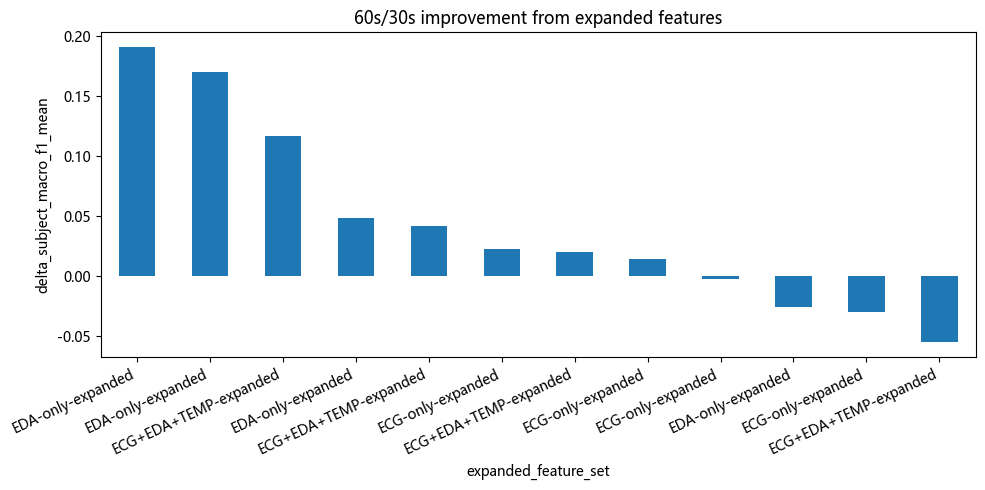

In [21]:
            top_delta_60 = expanded_compare_60.sort_values("delta_subject_macro_f1_mean", ascending=False)
            ax = top_delta_60.plot(
                x="expanded_feature_set",
                y="delta_subject_macro_f1_mean",
                kind="bar",
                figsize=(10, 5),
                legend=False,
            )
            ax.set_title("60s/30s improvement from expanded features")
            ax.set_ylabel("delta_subject_macro_f1_mean")
            ax.set_xlabel("expanded_feature_set")
            plt.xticks(rotation=25, ha="right")
            plt.tight_layout()
            plt.show()
            


In [22]:
            best_expanded_60 = expanded_loso_60.iloc[0]
            print("60s/30s 扩展特征最优配置：")
            print(best_expanded_60.to_string())
            


60s/30s 扩展特征最优配置：
model_name                                  LR
feature_set_name         ECG+EDA+TEMP-expanded
accuracy                               0.65826
macro_f1                              0.597574
subject_accuracy_mean                  0.64949
subject_accuracy_std                  0.200433
subject_macro_f1_mean                 0.520591
subject_macro_f1_std                  0.189596


            ### 这一步目前的结论

            就已经跑完的 `60s / 30s` 扩展实验来说：

            - `EDA-only-expanded` 提升非常明显
            - `LR + ECG+EDA+TEMP-expanded` 成为了新的最优 LOSO 配置
            - 这说明适度丰富 ECG / EDA 特征，确实有机会提升跨人泛化表现

            同时也要注意：

            - 不是所有模型都会因为特征变多而提升
            - 一些树模型在个别组合上可能反而下降
            - 所以“扩特征”必须配合正式评估协议，而不是只看单次高分
            


In [23]:
            expanded_10_files = sorted(p.name for p in EXPANDED_10.glob("*")) if EXPANDED_10.exists() else []
            print("10s/5s 扩展实验目录内容:")
            print(expanded_10_files)

            loso_10_expanded = EXPANDED_10 / "loso_summary.csv"
            compare_10_expanded = EXPANDED_10 / "baseline_vs_expanded_summary.csv"

            if loso_10_expanded.exists() and compare_10_expanded.exists():
                print("\n10s/5s 扩展结果已经完成：")
                display(pd.read_csv(loso_10_expanded).head())
                display(pd.read_csv(compare_10_expanded))
            else:
                print("\n10s/5s 扩展实验目前还没有完整落盘。")
                print("这通常意味着：特征表已生成，但完整 LOSO 评估还在运行或尚未输出总结文件。")
            


10s/5s 扩展实验目录内容:
['baseline_vs_expanded_summary.csv', 'best_loso_confusion_matrix.png', 'best_tree_feature_importance.csv', 'best_tree_feature_importance.png', 'feature_table.csv', 'loso_macro_f1.png', 'loso_results.json', 'loso_summary.csv', 'random_split_results.json', 'random_split_summary.csv']

10s/5s 扩展结果已经完成：


,model_name,feature_set_name,accuracy,macro_f1,subject_accuracy_mean,subject_accuracy_std,subject_macro_f1_mean,subject_macro_f1_std
0,LR,ECG+EDA+TEMP-expanded,0.586458,0.511029,0.581605,0.195112,0.469363,0.148249
1,SVM,EDA-only-expanded,0.664757,0.491216,0.665104,0.083761,0.466436,0.123783
2,RF,ECG+EDA+TEMP-expanded,0.778993,0.502288,0.782799,0.061150,0.461845,0.108521
3,LR,EDA-only,0.663715,0.465035,0.664239,0.101416,0.453122,0.145138
4,RF,ECG+EDA+TEMP,0.746701,0.480055,0.745819,0.106507,0.446266,0.127227


,window_config,model_name,baseline_feature_set,expanded_feature_set,baseline_subject_macro_f1_mean,expanded_subject_macro_f1_mean,delta_subject_macro_f1_mean
0,10s/5s,RF,EDA-only,EDA-only-expanded,0.370995,0.438634,0.067639
1,10s/5s,Boosting,EDA-only,EDA-only-expanded,0.352861,0.419574,0.066713
2,10s/5s,SVM,EDA-only,EDA-only-expanded,0.415811,0.466436,0.050625
3,10s/5s,LR,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.425111,0.469363,0.044251
4,10s/5s,Boosting,ECG-only,ECG-only-expanded,0.373092,0.409349,0.036257
5,10s/5s,SVM,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.410101,0.444412,0.034311
6,10s/5s,RF,ECG-only,ECG-only-expanded,0.394217,0.419458,0.025240
7,10s/5s,RF,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.446266,0.461845,0.015579
8,10s/5s,LR,ECG-only,ECG-only-expanded,0.362393,0.375665,0.013272
9,10s/5s,Boosting,ECG+EDA+TEMP,ECG+EDA+TEMP-expanded,0.439486,0.432008,-0.007478


            ## 10. 树模型特征重要性

            除了比较模型分数，还可以看树模型更偏好哪些特征。
            


In [24]:
            importance_df = pd.read_csv(ARTIFACT_60 / "best_tree_feature_importance.csv")
            importance_df.head(15)
            


,feature,importance
0,eda_scl_mean,0.301736
1,rr_mean_ms,0.102437
2,hr_mean,0.094909
3,temp_max,0.074396
4,temp_min,0.069170
5,temp_slope_per_min,0.053027
6,rmssd_ms,0.050038
7,pnn50,0.049080
8,eda_phasic_std,0.042941
9,ecg_quality_score,0.035036


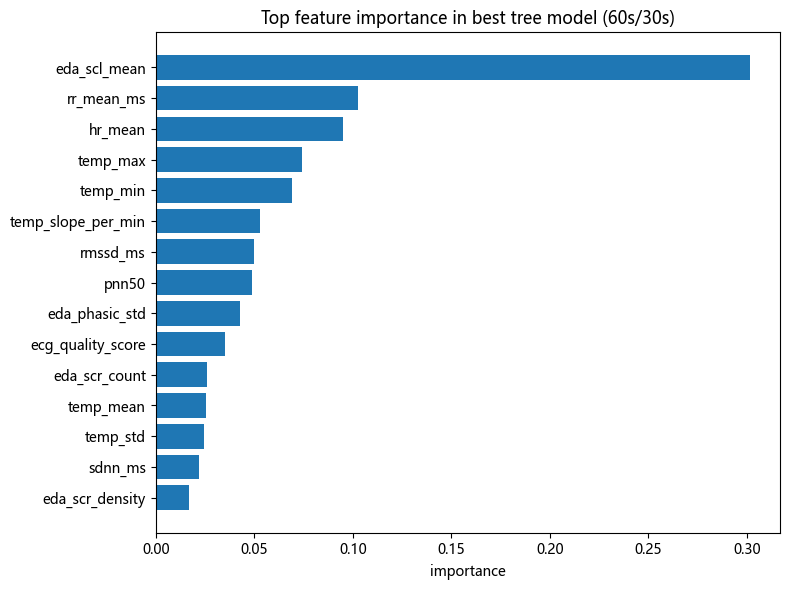

In [25]:
            top = importance_df.head(15).sort_values("importance", ascending=True)
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.barh(top["feature"], top["importance"])
            ax.set_title("Top feature importance in best tree model (60s/30s)")
            ax.set_xlabel("importance")
            plt.tight_layout()
            plt.show()
            


            ## 11. 这个工程到现在为止，已经完成了什么

            你可以把整个工程概括成下面这些步骤：

            1. 读懂 WESAD 的信号和问卷文件
            2. 把原始信号转成窗口级特征表
            3. 比较多个传统机器学习模型
            4. 正式使用 LOSO 做跨受试者评估
            5. 做三组窗长比较
            6. 扩展 ECG / EDA 特征并做新一轮验证
            7. 把实验结果整理成可教学、可汇报的材料
            


            ## 12. 当前最重要的结论

            到目前为止，这个项目最值得记住的结论不是某一个孤立分数，而是下面几件事：

            - `LOSO` 比 `random split` 更严格，也更真实
            - 多模态 `ECG+EDA+TEMP` 整体上比单模态更稳
            - 窗长缩短会增加样本量，但不保证提升跨人泛化
            - 适度扩展 ECG / EDA 特征，尤其是 EDA，已经在长窗上显示出明显增益
            


            ## 13. 下一步可以怎么做

            如果继续往前推进，比较自然的方向是：

            - 等 `10s / 5s` 扩展实验跑完，比较短窗是否也受益
            - 把扩展特征结果补进教学 notebook 和 README
            - 分析逐类混淆矩阵，看看哪一类最难分
            - 逐步从 WESAD 过渡到更贴近“焦虑”而不是“压力状态”的数据和标签
            - 最后再把结构化结果接入 Dify 的解释层或会诊层
            
